# Notebook 04 — ANN (Keras + Keras Tuner)

CSCI323 Modern Artificial Intelligence — Spring 2026 University of Wollongong Dubai (UOWD)

**Member 4:** Build and tune the ANN model.

**Objective:** To develop and optimize an Artificial Neural Network (ANN) model for predicting Dubai property prices and evaluate its performance against other regression models.

**Notebook Structure:**



1.   Setup & Data Loading
2.   Feature Selection & Data Preparation
1. Train-Test Split  
2. Data Preprocessing (Encoding & Scaling)  
1. Baseline ANN Model Training
2. Hyperparameter Tuning (Keras Tuner)
1. Final ANN Model Training
2. Model Evaluation (RMSE, MAE, R²)
1. Performance Visualisation (Loss Curve & Actual vs Predicted Plot)
2. Model Comparison
1. Final Conclusion





# Step 0 - Setup and Dependencies

In [ ]:
# Install Keras Tuner for ANN hyperparameter optimization
!pip install -q keras-tuner

All necessary libraries and dependencies for data handling, preprocessing, machine learning model development, neural network building, hyperparameter tuning, evaluation, and visualization are imported, and Google Drive is mounted to enable access to stored datasets.

In [ ]:
# Connect Google Drive to Colab to access datasets stored in Drive
from google.colab import drive
drive.mount('/content/drive')

# Import core data manipulation libraries
import pandas as pd
import numpy as np

# Import tools for splitting dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import preprocessing tools for encoding categorical data and scaling numerical data
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Import evaluation metrics for model performance assessment
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Import TensorFlow for building and training deep learning models
import tensorflow as tf

# Import layers and model structure for neural networks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Import Keras Tuner for hyperparameter optimization
import keras_tuner as kt

# Import visualization libraries for graphs and analysis
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow Version:", tf.__version__)
print("Libraries loaded successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow Version: 2.20.0
Libraries loaded successfully


#Step 1 - Load The Cleaned Dataset
The cleaned dataset `cleaned_data.csv `prepared by Member 1 was loaded from Google Drive and contains 1,637,984 rows and 16 columns with no missing values, making it ready for further processing and modeling.

In [ ]:
# Update this path to where you saved cleaned_data.csv
DATA_PATH = '/content/drive/MyDrive/CSCI323 - project dld transaction Data/cleaned_data.csv'

df = pd.read_csv(DATA_PATH)
df = df.sample(n=100000, random_state=42)

print("Sampled Shape:", df.shape)
df.head()

Sampled Shape: (100000, 16)


,trans_group_en,property_type_en,property_sub_type_en,property_usage_en,reg_type_en,area_name_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,year,month
990023,Mortgages,Villa,Villa,Residential,Existing Properties,Al Thanayah Fourth,Sports City Swimming Academy,Damac Properties,Marina Mall,3 B/R,0,536.57,2798000.0,5214.60,2012,8
395261,Sales,Unit,Flat,Residential,Off-Plan Properties,Bukadra,Unknown,Unknown,Unknown,1 B/R,1,78.56,1775781.0,22604.14,2025,6
731568,Sales,Unit,Flat,Residential,Off-Plan Properties,Burj Khalifa,Downtown Dubai,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1 B/R,1,78.87,1100000.0,13947.00,2013,3
77194,Mortgages,Villa,Unknown,Residential,Existing Properties,Al Thanayah Fourth,Sports City Swimming Academy,Damac Properties,Marina Mall,Unknown,0,549.52,5121672.0,9320.26,2020,6
463912,Mortgages,Unit,Office,Commercial,Existing Properties,Al Thanyah First,Burj Al Arab,Dubai Internet City,Mall of the Emirates,Office,1,73.72,763366.0,10354.94,2022,7


# Step 2 - Feature Selection & Data Preparation

This step defines the input features and target variable by separating the dataset into X and y, while also grouping categorical and numerical columns for preprocessing.

In [ ]:
# Separate independent variables (features) by removing the target column
X = df.drop(columns=["actual_worth"])

# Define the dependent variable (what we want to predict)
y = df["actual_worth"]

# List of categorical features that need encoding (e.g., OneHotEncoding)
categorical_cols = [
    "trans_group_en",
    "property_type_en",
    "property_sub_type_en",
    "property_usage_en",
    "reg_type_en",
    "area_name_en",
    "nearest_landmark_en",
    "nearest_metro_en",
    "nearest_mall_en",
    "rooms_en"
]

# List of numerical features that will be scaled or used directly in the model
numerical_cols = [
    "has_parking",
    "procedure_area",
    "meter_sale_price",
    "year",
    "month"
]

# Step 3 - Train-Test Split
The dataset is split into training and testing sets (80% training and 20% testing) using `train_test_split` to allow model training on one portion of the data and evaluation on unseen data for performance assessment.

In [ ]:
# Split the dataset into training and testing sets
# 80% of the data is used for training and 20% is used for testing
# random_state ensures reproducibility of the split results
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
# Log transform target variable to handle price skewness
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
print("Log transform done")
print(f"Original price range: {y_train.min():,.0f} to {y_train.max():,.0f}")
print(f"Log range: {y_train_log.min():.2f} to {y_train_log.max():.2f}")

Log transform done
Original price range: 11,323 to 500,000,000
Log range: 9.33 to 20.03


# Step 4 - Data Preprocessing (Encoding & Scaling)
Categorical features are encoded and numerical features are scaled using a `ColumnTransformer`, and the transformed training and testing datasets are prepared for model input.

In [ ]:
# Create a preprocessing pipeline for categorical and numerical features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat", # Categorical data encoding
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num", # Numerical data scaling
            StandardScaler(),
            numerical_cols
        )
    ]
)

# Fit the preprocessor on training data and transform it
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same transformation to test data
X_test_processed = preprocessor.transform(X_test)

# Display the shape of processed datasets
print("Training Shape:", X_train_processed.shape)
print("Testing Shape:", X_test_processed.shape)

Training Shape: (80000, 327)
Testing Shape: (20000, 327)


# Step 5 - Baseline ANN Model Training
A **Sequential Artificial Neural Network (ANN)** is defined using fully connected **Dense layers**, where the input size is set based on the processed training data features.

The model consists of three hidden layers **(256, 128 and 64 neurons)** with **ReLU activation** and **Dropout layers** to reduce overfitting, followed by a **single linear output layer** for regression.

The model is compiled using the **Adam optimizer** with a learning rate of **0.001**, mean squared error as the loss function, and mean absolute error as the evaluation metric.

It is then trained on the processed training data with a **20% validation split** over **20 epochs** and a **batch size of 64**.

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

input_dim = X_train_processed.shape[1]

model = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),

    Dense(1, activation='linear')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_processed,
    y_train_log,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 38.4311 - mae: 4.1342 - val_loss: 0.4418 - val_mae: 0.4520
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 1.7344 - mae: 0.9931 - val_loss: 0.3702 - val_mae: 0.4013
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.2026 - mae: 0.8282 - val_loss: 0.2695 - val_mae: 0.3378
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.9189 - mae: 0.7265 - val_loss: 0.2408 - val_mae: 0.3268
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.7413 - mae: 0.6559 - val_loss: 0.2869 - val_mae: 0.3122
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.6467 - mae: 0.6148 - val_loss: 0.2110 - val_mae: 0.2889
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.5938 - mae: 0.5894 - val_loss: 0.2303 - val_mae: 0.3097
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.5535 - mae: 0.5714 - val_loss: 0.1999 - val_mae: 0.2836
Epoch 9/50
1000/1000 ━━━━━━━━━━━━━━

# Step 6 - Hyperparameter Tuning (Keras Tuner)
The function `build_model` is defined to construct a tunable Artificial Neural Network (ANN) using Keras Tuner, where hyperparameters such as the number of neurons, dropout rate, and learning rate are dynamically selected to optimize model performance during training.

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

def build_model(hp):
    model = Sequential()

    # First hidden layer
    model.add(Dense(
        units=hp.Int('units1', min_value=128, max_value=512, step=128),
        activation='relu',
        input_shape=(X_train_processed.shape[1],)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Choice('dropout1', values=[0.2, 0.3])))

    # Second hidden layer
    model.add(Dense(
        units=hp.Int('units2', min_value=64, max_value=256, step=64),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Choice('dropout2', values=[0.1, 0.2])))

    # Third hidden layer
    model.add(Dense(
        units=hp.Int('units3', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(BatchNormalization())

    # Output layer
    model.add(Dense(1, activation='linear'))

    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', values=[0.001, 0.0001])),
        loss='mse',
        metrics=['mae']
    )
    return model

A **Random Search strategy** is used to evaluate different combinations of **ANN hyperparameters** on a subset of the training data, allowing Keras Tuner to identify the model configuration that produces the best validation performance.

In [ ]:
# Create a smaller subset of the training data to speed up hyperparameter tuning
X_train_gs, _, y_train_gs_log, _ = train_test_split(
    X_train_processed,
    y_train_log,
    test_size=0.8,
    random_state=42
)

# Initialize Keras Tuner with Random Search strategy
tuner = kt.RandomSearch(
    build_model,                        # Model-building function
    objective="val_loss",               # Optimize based on validation loss
    max_trials=10,                      # Number of hyperparameter combinations to test
    overwrite=True,                     # Replace previous tuning results
    directory="ann_tuner",              # Folder to save tuning results
    project_name="dubai_real_estate"
)

# Start hyperparameter search on the training subset
tuner.search(
    X_train_gs,
    y_train_gs_log,
    validation_split=0.2,   # Reserve 20% for validation
    epochs=10,              # Train each trial for 10 epochs
    batch_size=64
)

Trial 10 Complete [00h 00m 19s]
val_loss: 0.21956545114517212

Best val_loss So Far: 0.1746678203344345
Total elapsed time: 00h 04m 12s


The optimal hyperparameter values identified by Keras Tuner are retrieved and displayed, including the number of neurons in each hidden layer, dropout rate, and learning rate for the best-performing ANN model.

In [ ]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Units Layer 1:", best_hp.get("units1"))
print("Best Units Layer 2:", best_hp.get("units2"))
print("Best Units Layer 3:", best_hp.get("units3"))
print("Best Dropout 1:", best_hp.get("dropout1"))
print("Best Dropout 2:", best_hp.get("dropout2"))
print("Best Learning Rate:", best_hp.get("learning_rate"))

Best Units Layer 1: 384
Best Units Layer 2: 192
Best Units Layer 3: 32
Best Dropout 1: 0.2
Best Dropout 2: 0.2
Best Learning Rate: 0.001


# Step 7 - Final ANN Model Training
The ANN model is rebuilt using the optimal hyperparameters identified by Keras Tuner and then trained on the processed training data to produce the final optimized model.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)

history_best = best_model.fit(
    X_train_processed,
    y_train_log,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.1312 - mae: 0.2473 - val_loss: 0.1533 - val_mae: 0.2426 - learning_rate: 0.0010
Epoch 2/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.1271 - mae: 0.2448 - val_loss: 0.1355 - val_mae: 0.2264 - learning_rate: 0.0010
Epoch 3/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.1224 - mae: 0.2409 - val_loss: 0.1388 - val_mae: 0.2230 - learning_rate: 0.0010
Epoch 4/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.1222 - mae: 0.2395 - val_loss: 0.1368 - val_mae: 0.2263 - learning_rate: 0.0010
Epoch 5/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.1214 - mae: 0.2413 - val_loss: 0.1574 - val_mae: 0.2607 - learning_rate: 0.0010
Epoch 6/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.1199 - mae: 0.2389 - val_loss: 0.1293 - val_mae: 0.2168 - learning_rate: 0.0010
Epoch 7/100
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 0.1192 - mae: 0.2377 - val_loss: 0.1510 - val_mae: 0.247

#Step 8 -  Model Evaluation (RMSE, MAE, R²)
The trained ANN model is then used to generate predictions on the test dataset, which are then used to evaluate model performance using RMSE, MAE, and R² metrics.

In [ ]:
# Generate predictions in log scale then convert back to AED
y_pred_log = best_model.predict(X_test_processed).flatten()
y_pred = np.expm1(y_pred_log)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [ ]:
# Evaluate in log scale for stable R² calculation
rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
mae_log = mean_absolute_error(y_test_log, y_pred_log)
r2_log = r2_score(y_test_log, y_pred_log)

# Also calculate AED scale metrics using clipped predictions
y_pred_clipped = np.clip(y_pred, 0, 500_000_000)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_clipped))
mae = mean_absolute_error(y_test, y_pred_clipped)
r2 = r2_score(y_test, y_pred_clipped)

print("ANN Results (Log Scale — for model quality assessment)")
print("-" * 45)
print(f"{'RMSE (log)':<15} | {rmse_log:>12.4f}")
print(f"{'MAE (log)':<15} | {mae_log:>12.4f}")
print(f"{'R² (log)':<15} | {r2_log:>12.4f}")
print()
print("ANN Results (AED Scale — clipped at 500M)")
print("-" * 45)
print(f"{'RMSE':<15} | {rmse:>15,.2f}")
print(f"{'MAE':<15} | {mae:>15,.2f}")
print(f"{'R²':<15} | {r2:>12.4f}")
print("-" * 45)

ANN Results (Log Scale — for model quality assessment)
---------------------------------------------
RMSE (log)      |       0.3526
MAE (log)       |       0.2043
R² (log)        |       0.8740

ANN Results (AED Scale — clipped at 500M)
---------------------------------------------
RMSE            |    9,781,884.41
MAE             |    1,162,443.69
R²              |       0.3516
---------------------------------------------


#Step 9 - Performance Visualisation (Loss Curve & Actual vs Predicted Plot)

##Loss Curve
This step visualizes the training and validation loss across epochs to assess the learning behavior of the ANN model and identify potential overfitting or underfitting.

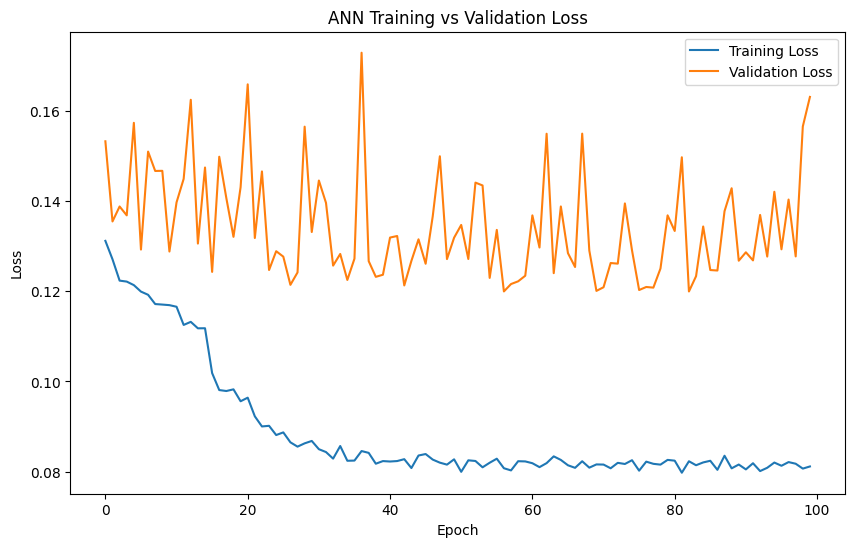

In [ ]:
# Create a figure for plotting the ANN training history
plt.figure(figsize=(10,6))

# Plot training loss values across epochs
plt.plot(
    history_best.history["loss"],
    label="Training Loss"
)

# Plot validation loss values across epochs
plt.plot(
    history_best.history["val_loss"],
    label="Validation Loss"
)

plt.title("ANN Training vs Validation Loss")

# Label x-axis as epochs
plt.xlabel("Epoch")

# Label y-axis as loss
plt.ylabel("Loss")

# Display legend for the plotted lines
plt.legend()

plt.savefig('ann_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

##Actual vs Predicted Values Visualization
This plot compares actual and predicted property prices using a scatter graph. The diagonal red dotted line shows perfect predictions, and the closeness of points to this line indicates how accurate the model is.

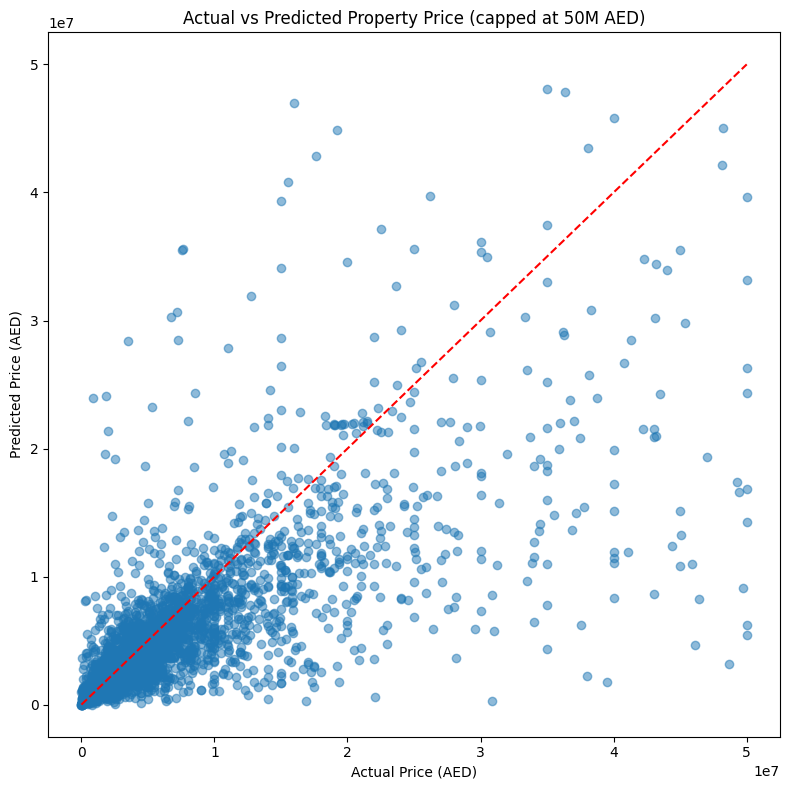

In [ ]:
plt.figure(figsize=(8, 8))

# Cap both axes at 50M for better visibility
mask = (y_test <= 50_000_000) & (y_pred <= 50_000_000)
y_test_plot = y_test[mask]
y_pred_plot = y_pred[mask]

plt.scatter(y_test_plot, y_pred_plot, alpha=0.5)

plt.plot(
    [y_test_plot.min(), y_test_plot.max()],
    [y_test_plot.min(), y_test_plot.max()],
    "r--"
)

plt.xlabel("Actual Price (AED)")
plt.ylabel("Predicted Price (AED)")
plt.title("Actual vs Predicted Property Price (capped at 50M AED)")
plt.tight_layout()
plt.savefig('ann_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

#Step 10 - Model Comparison
This step creates a comparison table to evaluate multiple regression models **Linear Regression, Random Forest, and ANN**  using performance metrics such as RMSE, MAE, and R².

It then identifies the best-performing model based on the highest R² score and displays it separately using a print statement.

This allows easy comparison and clear identification of the model with the best predictive performance.

In [ ]:
from IPython.display import display

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "ANN"],
    "RMSE (AED)": [10283692.80, 4207139.00, 9781884.41],
    "MAE (AED)": [2736563.51, 201542.00, 1162443.69],
    "R² (AED scale)": [0.2834, 0.8945, 0.3516],
    "R² (log scale)": ["N/A", "N/A", 0.8740]
})

comparison_df["Best Model"] = comparison_df["R² (AED scale)"] == comparison_df["R² (AED scale)"].max()
display(comparison_df)

best_model_name = comparison_df.loc[comparison_df["R² (AED scale)"].idxmax(), "Model"]
print("\n===================================")
print("BEST MODEL RESULT")
print("===================================")
print(f"The best performing model is: {best_model_name}")
print("===================================")

,Model,RMSE (AED),MAE (AED),R² (AED scale),R² (log scale),Best Model
0,Linear Regression,10283692.80,2736563.51,0.2834,N/A,False
1,Random Forest,4207139.00,201542.00,0.8945,N/A,True
2,ANN,9781884.41,1162443.69,0.3516,0.874,False



BEST MODEL RESULT
The best performing model is: Random Forest


Among the three regression models evaluated, **Random Forest achieved the best performance** with an R² of 0.8945 and MAE of 201,542 AED on the test set, significantly outperforming both Linear Regression and ANN on the AED scale.

The ANN achieved an R² of 0.8740 in log scale, showing strong learning capability. However when predictions are converted back to AED, the R² drops to 0.35 due to amplification errors on extreme luxury property prices during the inverse log transformation. This is a known limitation of ANN regression on heavily skewed price data.

Linear Regression performed the weakest at R² of 0.28, confirming that property price prediction on this dataset requires non-linear models to capture the complexity of Dubai's real estate market.

**Conclusion: Random Forest is the recommended model for deployment.**

#Step 11 - Final Conclusion

In [ ]:
final_results = pd.DataFrame({
    "Metric": [
        "Root Mean Squared Error (RMSE)",
        "Mean Absolute Error (MAE)",
        "R² Score (AED scale)",
        "R² Score (log scale)"
    ],
    "Value": [
        f"{rmse:,.2f} AED",
        f"{mae:,.2f} AED",
        f"{r2:.4f}",
        f"{r2_log:.4f}"
    ]
})
final_results

,Metric,Value
0,Root Mean Squared Error (RMSE),"9,781,884.41 AED"
1,Mean Absolute Error (MAE),"1,162,443.69 AED"
2,R² Score (AED scale),0.3516
3,R² Score (log scale),0.8740
